## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Amelia Chen

**Date:** 9/30/2026

### Q1 Responses

1. **What is the difference between regression and classification?**

Regression and classification are both types of algorithms that are used to make predictions about data. Regression is used to make predictions about numerical data, while classification is used to make predictions about categorical data.

For kNN, to use regression to make a prediction about the $\hat{y}$ of a new observation $\hat{x}$, we must first compute the distance between $\hat{x}$ and every $x_i$. With the distances calculated, we selected the nearest $k$ neighbors, which have outcomes $y^*_1…y^*_k$. The final value of $\hat{y}$ is the average of our selected outcomes, or $\frac{1}{k} \sum_{j=1}^k y^*_j$.

For kNN classification, we start with the same step of computing the distance between our new observation $\hat{x}$ and all other $x_i$, then selecting the $k$ nearest neighbors. From the selected $k$, we calculate the proportion of each category by dividing its count by $k$. The class with the highest proportion is the predicted $\hat{y}$ value.

2. **What is a confusion table? What does it help us understand about a model's performance?**

A confusion table is a method of representing the accuracy of predictions. The rows of the table represent the actual classes, and the columns of the table represent the predicted classes. In this way, the diagonals of the table represent when the actual classes intersect/match the predicted classes, reflecting the accuracy of the model’s performance. The off-diagonal cells of the table represent when the actual classes did not match the model’s prediction. Being able to visualize the class-by-class accuracy of the model allows us to understand not just the overall accuracy/inaccuracy, but also if the model performs better on some features compared to others.

3. **What does the SSE quantify about a particular model?**

The SSE is a metric for understanding the accuracy of a model. The formula for SSE takes each of the residuals, squares them, and adds them together. Each residual quantifies the prediction error: how far away the prediction was from the actual value. A residual of 0 means the prediction was the same as the actual; a residual greater than 0 means the model underpredicted; and a residual less then 0 means the model overpredicted. In SSE, we want to square all of the residuals so that any negative residuals don’t cancel out the positive residuals. Next, we add all of the residuals together, resulting in a value that represents the overall error of the model. In the context of kNN, calculating the SSE is useful because we can test out different $k$ values and figure out which one results in the lowest error/SSE.

4. **What are overfitting and underfitting?**

When we train a model on training data to prepare it to be used for making predictions, that is described as “fitting” the model. Depending on how the model was trained, our actual test/validation results may point to the model being either overfitted or underfitted. In the context of kNN, the general pattern is that as $k$ increases, the model averages more observations to make it’s predictions, gradually leading to less and less variation.

Overfitting occurs when $k$ remains too small: the model has too few observations to draw from, so the pattern that the model is intended to capture is not yet visible. Noisy data points result in high variation in predictions. On the other hand, underfitting occurs when $k$ becomes too big: the model starts to average too many observations, and any meaningful patterns get lost. The result is that the model provides the same, dominant prediction every single time, even for very different $x$ points.

5. **Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?**

It is necessary to split the data into training and testing sets to optimize the model’s ability to generalize. We want to be able to train the model on a small subset of the data and apply the model to any data that is a similar form. If we were to train and test the model on the same subset of data, the model could potentially learn the data perfectly in training, then when we test it we will find that it has 100% accuracy. This is misleading, as if we were to apply the model to some new data that it was unfamiliar with, we may find that it performs very poorly. The model didn’t actually learn to recognize general patterns, it only learned the patterns specific to the training data. Similarly, we want to choose our $k$ value based off of the accuracy/SSE of the validation data, not the training data. The validation data is intended to provide insights about the model’s performance on generalized data, so lower error in validation indicates, generally, a more accurate model.

6. **With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**

Reporting a class label as a prediction is a simpler approach that provides a concrete classification immediately. However, it strips away the context of the prediction. With the probability distribution approach, we are able to see exactly how many neighbors belonged to each class. This may be useful when trying to decide $k$ values, as we want to decide what value of $k$ can overcome noise while still capturing the desired pattern. The drawback of the probability distribution is that it may require additional processing to determine what the actual classification should be. 

As an example, let’s say we have selected $k$=5:
- Case 1: point $x$’s 5 neighbors are SUV
- Case 2: point $y$ has 3 neighbors that are SUV, 2 neighbors that are car

If we only received the prediction as output, in both cases we would have simply accepted that points $x$ and $y$ are likely SUV’s. However, if we had seen the probability distribution, we would have been able to see clearly that point $x$ is likely an SUV, and we may have considered the possibility that point $y$ is a car that has more neighbors that are SUV’s due to noise/low $k$ value.

(338, 4) 

voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object 

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None


<Figure size 640x480 with 0 Axes>

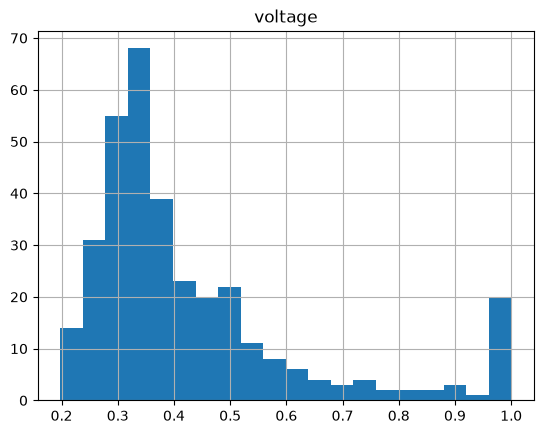

,mean,median,mode,min,max,Q1,Q3
0,0.431,0.36,1.0,0.198,1.0,0.31,0.483


<Figure size 640x480 with 0 Axes>

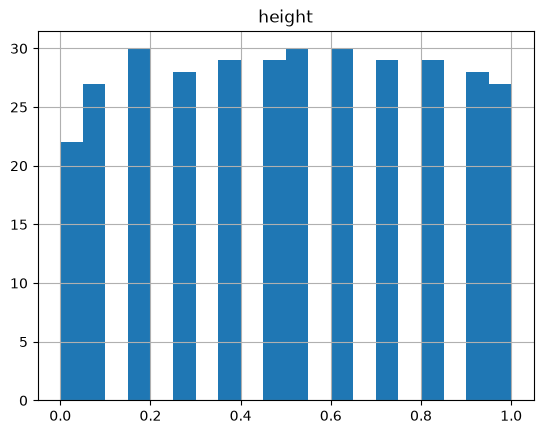

,mean,median,mode,min,max,Q1,Q3
0,0.509,0.545,0.182,0.0,1.0,0.273,0.727


<Figure size 640x480 with 0 Axes>

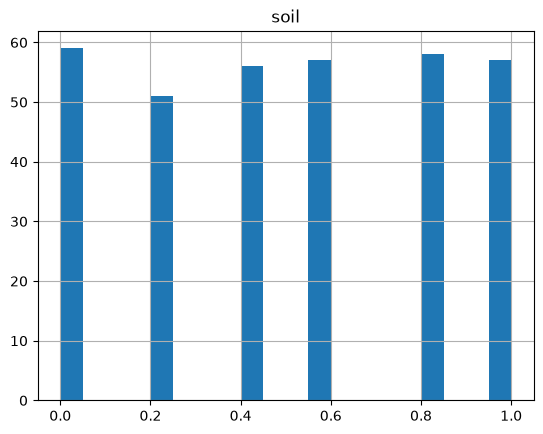

,mean,median,mode,min,max,Q1,Q3
0,0.504,0.6,0.0,0.0,1.0,0.2,0.8


<Figure size 640x480 with 0 Axes>

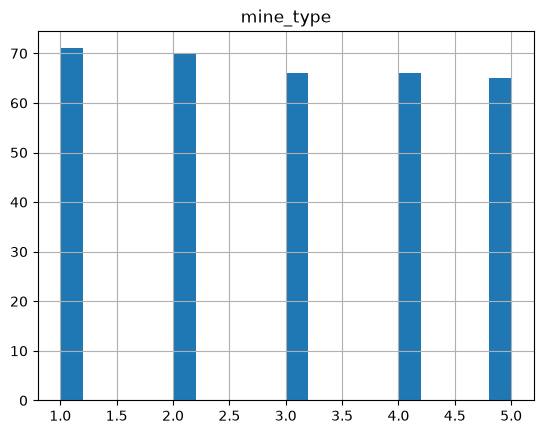

,mean,median,mode,min,max,Q1,Q3
0,2.953,3.0,1,1,5,2.0,4.0


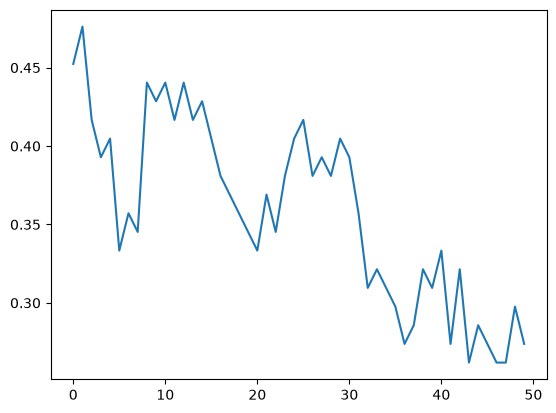

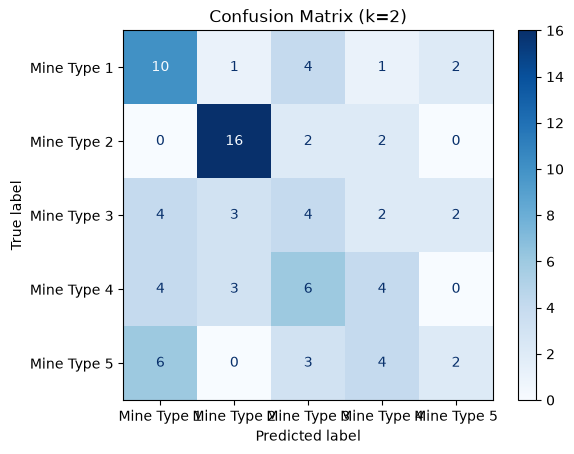

accuracy:  0.4235294117647059


"\nNotice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. \nPlease explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.\n\nGiven the patterns in the errors the model makes, I would adivse someone who is using this predictive model in practice not to trust\nclassifications of Mine Types 3, 4, and 5, as these have high misclassification rates. For Mine Types 2 and 1, I would recommend someone\nto look at the probability distributions of classification predictions, as the additional context may be useful in making informed predictions\nabout classifications.\n"

In [12]:
# Sources:
# https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbor-algorithm-in-python/
# https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

########## ========== Q2.1 ========== ##########
# Load the data. Perform some EDA, summarizing the target label and the features.
filepath = 'data/land_mines.csv'
df = pd.read_csv(filepath, low_memory=False)

print(df.shape, '\n')   # output: (338, 4)
print(df.dtypes, '\n') 
print(df.head())
print(df.info())        # output: all 4 columns have 338 non-nulls = no missing values

plt.figure()
df.hist(column="voltage", bins=20)  # create a histogram for the voltage column
plt.savefig("voltage_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the voltage variable with summary statistics
    "mean": [df["voltage"].mean()],
    "median": [df["voltage"].median()],
    "mode": [df["voltage"].mode().iloc[0]],
    "min" : df["voltage"].min(),
    "max": df["voltage"].max(),
    "Q1": [df["voltage"].quantile(0.25)],
    "Q3": [df["voltage"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode   min	    max	    Q1	    Q3
0.431	0.36	1.0	   0.198	1.0	   0.31	   0.483

Most skewed histogram, steep increase from around 0.2 to a peak around 0.35.
Then drops steeply again until around 0.45, then continues to decrease slowly.
Another sharp peak at 1.0.
'''

plt.figure()
df.hist(column="height", bins=20)  # create a histogram for the height column
plt.savefig("height_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the height variable with summary statistics
    "mean": [df["height"].mean()],
    "median": [df["height"].median()],
    "mode": [df["height"].mode().iloc[0]],
    "min" : df["height"].min(),
    "max": df["height"].max(),
    "Q1": [df["height"].quantile(0.25)],
    "Q3": [df["height"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode	min	   max	 Q1	     Q3
0.509	0.545	0.182	0.0	   1.0	 0.273	 0.727

Height ranges from 0.0-1.0, histogram has a slight peak in the middle.
Overall still relatively equally dustributed
'''

plt.figure()
df.hist(column="soil", bins=20)  # create a histogram for the soil column
plt.savefig("soil_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the soil variable with summary statistics
    "mean": [df["soil"].mean()],
    "median": [df["soil"].median()],
    "mode": [df["soil"].mode().iloc[0]],
    "min" : df["soil"].min(),
    "max": df["soil"].max(),
    "Q1": [df["soil"].quantile(0.25)],
    "Q3": [df["soil"].quantile(0.75)],
})
display(summary.round(3))

'''

mean	median	mode	min	   max	  Q1	Q3
0.504	0.6	     0.0	0.0	   1.0	  0.2	0.8

Soil values appear to be either 0.0, 0.2, 0.4, 0.6, 0.8, and 1.0.
Relatively evenly distributed.
'''

plt.figure()
df.hist(column="mine_type", bins=20)  # create a histogram for the mine_type column
plt.savefig("mine_type_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the mine_type variable with summary statistics
    "mean": [df["mine_type"].mean()],
    "median": [df["mine_type"].median()],
    "mode": [df["mine_type"].mode().iloc[0]],
    "min" : df["mine_type"].min(),
    "max": df["mine_type"].max(),
    "Q1": [df["mine_type"].quantile(0.25)],
    "Q3": [df["mine_type"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode	min	   max	   Q1	   Q3
2.953	3.0	     1	     1	    5	   2.0	   4.0

Observed that the 5 mine types are relatively evenly distributed.
'''


########## ========== Q2.2 ========== ##########
# Split the sample 50/50 into training and test/validation sets.
# (The smaller the data are, the more equal the split should be, in my experience:
# Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

# first split into 50/50 then split latter 50 into 50/50
# result: 50% train, 25% validate, 25% test
eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_test_raw,
    eval_y_train,
    eval_y_valid_test,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=65
)

(
    eval_X_valid_raw,
    classification_X_test_raw,
    eval_y_valid,
    classification_y_test,
) = train_test_split(
    eval_X_valid_test_raw, eval_y_valid_test, test_size=0.50, random_state=65
)

# fit the scalar on the training data, then transform both the training and validation data
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)


########## ========== Q2.3 ========== ##########
# Build a $k$-NN classifier. Explain how you select k.

# test out fitting the model on a range of k values
# for each k, create a classifier and fit it with that k value.
# predict results on the validation dataset and calculate the accuracy score
# choose the highest accuracy as eval_k_star
eval_ks = np.arange(1, 51)
eval_valid_accuracy = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_valid_accuracy.append(accuracy_score(eval_y_valid, eval_valid_hat))
eval_k_star = int(eval_ks[np.argmax(eval_valid_accuracy)])

# show the k vs validation accuracy scores plot
k_plot = np.array(eval_valid_accuracy)
plt.plot(k_plot)
plt.show()

# fit the regressor on the best k value
classification_k = eval_k_star
classification_model = KNeighborsClassifier(n_neighbors = classification_k).fit(
    eval_X_train_scaled, eval_y_train
)


########## ========== Q2.4 ========== ##########
# Print a confusion table for the optimal model, comparing predicted and actual class label on the test set.

# predict on the test data
classification_X_test_scaled = eval_scaler.transform(classification_X_test_raw)
y_pred = classification_model.predict(classification_X_test_scaled)

# create the confusion matrix
cm = confusion_matrix(classification_y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mine Type 1", "Mine Type 2", "Mine Type 3", "Mine Type 4", "Mine Type 5"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k={classification_k})")
plt.grid(False)
plt.show()

print("accuracy: ", accuracy_score(classification_y_test, y_pred))

'''
How accurate is it? Where is performance more or less accurate?

The overall accuracy of the model is around 0.424. Based on the confusion matrix, we observe that the model makes the most accurate
predictions for Mine Type 2 with 16 accurate predictions (80.00% class accuracy), followed by Mine Type 1 with 10 accurate predictions 
(55.56% class accuracy). For Mine Types 3 and 4, the model only predicts 4 classes correctly (26.67% and 23.53% class accuracy, respectively).
For Mine Type 5, the model only predicts 2 classes correctly (13.33% class accuracy). The model often mistakes Mine Type 5 for Mine type 1, 
as well as Mine Type 4 for Mine Type 3 (6 misclassifications each). All other off-diagonal cells have misclassifications ranging from 0-4.
'''

########## ========== Q2.5 ========== ##########
'''
Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. 
Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Given the patterns in the errors the model makes, I would adivse someone who is using this predictive model in practice not to trust
classifications of Mine Types 3, 4, and 5, as these have high misclassification rates. For Mine Types 2 and 1, I would recommend someone
to look at the probability distributions of classification predictions, as the additional context may be useful in making informed predictions
about classifications.
'''


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** ec6b7c79f0ee22690e98e224a8f6af20db8c998b
- **AI tool and model used:** Claude Sonnet 5.5 Medium Effort

### *Prompts used

1. Hi Claude, can you check my understanding of the following questions based on my responses? [responses to Q1]
2. Next, can you review my code for a kNN case study? The instructions are written in the comments. I have attached my code and the dataset: [code for Q2]

### *AI-proposed changes


1. Q2: Confusion table. The structure is right. One word choice to fix: you say the model may perform better on some "features," but you mean classes. Features are the predictors (the x variables). You could also add that the off-diagonal cells show which classes get confused with each other (e.g., SUVs mislabeled as cars), not just that errors happened.
2. Q3: SSE. Your residual sign convention (positive means underpredicted) is correct if residual = actual − predicted. State that definition explicitly so the sign logic is checkable. Squaring does two things: it stops cancellation, and it penalizes large errors more heavily than small ones. The second point is worth including. The weak spot is the last sentence. Choosing k by lowest SSE only works if the SSE is computed on the validation/test data. On the training data, k = 1 always gives SSE = 0, because each point is its own nearest neighbor. This connects directly to your Q5 answer, so tie them together.
3. Q4: Overfitting and underfitting. Two refinements: Your phrase "the pattern is not yet visible" for small k isn't quite accurate. The pattern is still there, but each prediction depends on so few points that the model ends up fitting the noise. Frame it in terms of error. An overfit model has low training error but high test error. An underfit model has high error on both. Naming the bias-variance tradeoff (small k means low bias and high variance, large k the reverse) would make this answer complete.
4. Q5: Train/test split. The reasoning about 100% training accuracy being misleading is good, and it holds especially for kNN with k = 1. A few adjustments: You wrote that we train on "a small subset" of the data. Usually the training set is the larger portion (e.g., 70–80%). The question asks how the split "improves model performance." Strictly, the split doesn't improve the model by itself. It gives an honest estimate of how the model does on unseen data, which lets us pick the k that generalizes best. Saying so directly would sharpen your answer.
5. Q6: Label vs. probability distribution. I'd sharpen the takeaway: the distribution reveals confidence. Case 1 is a unanimous 5/5, while Case 2 is a 3/5 vote, so the label "SUV" hides a big difference in certainty. Other points you could add: The label's strengths are simplicity and being immediately usable. With kNN the probabilities are coarse (multiples of 1/k), and the label can hide ties.
6. Q2.2: Split. Your comment worries about a class landing entirely in one split. train_test_split(..., stratify=y) guarantees every class appears in each split in proportion, so I'd add it to both splits. With only 85 test points, it also steadies the per-class counts.
7. Q2.3: Choosing k. The plot: plt.plot(k_plot) puts index 0–49 on the x-axis, so the plot is shifted by one from the real k values. Use plt.plot(eval_ks, eval_valid_accuracy) and add axis labels and a title. The comment: "fit the regressor" should say "classifier." The question asks you to explain how you select k. Right now that lives in code comments, so add a short written explanation of the search over k = 1–50, the validation accuracy, and the tie handling.
8. Q2.4: Confusion table. The question says to print a confusion table, and you show a plot. Add print(cm) as well, or a labeled pd.DataFrame. The labels are hard-coded. Using sorted(df.mine_type.unique()) is safer. You imported classification_report but never used it. It gives recall and precision per class, which matters for Q2.5. Add a baseline. With five roughly equal classes, random guessing gets about 20%, and always guessing the most common class gets about 24% on this test set. So 42% is clearly better than chance, but not good. Class sizes in the test set are only 15–20, so a figure like 13.33% is just 2 of 15. These percentages are noisy.
9. Q2.5: Advice for using the model. This is where I'd rework the answer. The question's hint says you can have many accurate predictions for a type and still make many mistakes. That is the difference between recall and precision: Recall (rows): of the mines that really are type j, how many did the model find? This is the "class accuracy" you computed. Precision (columns): when the model says type j, how often is it right? This is what a person in the field actually cares about. 

Here are the precision numbers from the run:

Predicted type	Precision
1	            0.42 (10 of 24)
2	            0.70 (16 of 23)
3	            0.21 (4 of 19)
4	            0.31 (4 of 13)
5	            0.33 (2 of 6)

Type 1 is the example the hint is pointing at. It has the second-best recall (56%), but when the model says "Type 1," it's wrong more than half the time, because types 3, 4, and 5 are often mislabeled as 1. Your current advice (distrust 3, 4, 5, and look at probabilities for 1 and 2) misses this. Only a "Type 2" prediction is reasonably trustworthy.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Claude pointed out that I used the wrong terminology in one place, writing "features" instead of "classes." Claude also said I could strengthen my response by adding a line about how specific confusions could be visualized. This was something that I had intended to address previosly when I had tried to describe the off-diagonal cells, but I see how I could be more explicit in describing the confusion.  |
| 2 | Accept | I used the definition of residuals from the slides but it makes sense that I should define it as residual=actual-predicted in my response as well. I also recognize that I missed the fact that squaring the SSE penalizes larger errors more. This is something I have learned in previous classes and forgot to include. I also realized when I wrote about testing k values, I was writing with the assumption that it would happen during the validation phase, as that was what we learned. Claude pointed out that I should write this out explicitly, which I agree would make my response clearer. |
| 3 | Modify | Claude wrote that the phrase "the pattern is not yet visible" is not exactly accurate, and that the pattern is there but the model fits the noise instead. What I was trying to say with this was the within the $k$ selected points, there is more noise than meaningful data points, which obscure the desired pattern. I slightly adjusted my wording to say "overshadowed by noise" instead. I'm deciding not to include Claude's recommendations about error and the bias-variance tradeoff. I have learned about this before in previous classes, but since we have not talked about it specifically in this class, I'm keeping my response centered around the concepts included in our slides. |
| 4 | Reject | I'm keeping my description of "a small subset" of data, as what I am trying to say is that we are usually trying to make a model that can be shared with others and applied to data beyond the initial dataset. For the second recommendation, I think Claude is focusing too much on the semantics of the question; my understanding of what the question is trying to get at is the benefit of splitting data into training/testing sets vs. not splitting at all. |
| 5 | Accept | I think Claude bringing up the "confidence" and "certainty" keywords are a good suggestion to make my response stronger. I also think the other points it brought up, especially the one about ties, is an important edge case to address. |
| 6 | Reject | Claude recommends adding stratify=y as an argument to the train_test_split function. Since we didn't learn this, I'm choosing not to include it. |
| 7 | Accept | Claude gave me some advice on creating a better plot of the k vs. accuracy scores plot. I implemented it and checked the output plot, which looks about the same, but then I checked the matplotlib.pyplot.plot documentation (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) which does write that simply calling plot(array) uses indices 0-N-1. Next, I updated my comment, which wrongfully wrote "regressor" instead of "classifier." Lastly, I agreed that since the question asked to desribe how k was selected I should answer that in a little written blurb. |
| 8 | Modify | I used a source I found online for creating my confusion matrix, so I'm just going to keep that instead of implementing Claude's suggestions. I am going to use the results of the classification_report function to calculate precision/recall based on my understanding from suggestion 9. I liked Claude's suggestion of adding a baseline, as it ties into my EDA and helps shape perception of the significance of the results. Lastly, I disagreed with Claude saying that the percentages are noisy, I think 13.33% is much easier to understand than 2/15, and it also standardizes the measures across the different classes. |
| 9 | Accept | Claude provided a really helpful explanation of recall vs. precision as these are metrics I have used before for other classes but would sometimes still get confused about. I used this source to verify Claude's explanation: https://www.geeksforgeeks.org/machine-learning/precision-and-recall-in-machine-learning/. With this understanding, I was able to see that my initial answer was focused on recall, which is less of a descriptor of the errors the model tends to make since it starts with knowledge of the true label. This also made me realize that adding precision would make my response to question 2.4. more complete|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Q1 Responses

1. **What is the difference between regression and classification?**

Regression and classification are both types of algorithms that are used to make predictions about data. Regression is used to make predictions about numerical data, while classification is used to make predictions about categorical data.

For kNN, to use regression to make a prediction about the $\hat{y}$ of a new observation $\hat{x}$, we must first compute the distance between $\hat{x}$ and every $x_i$. With the distances calculated, we selected the nearest $k$ neighbors, which have outcomes $y^*_1…y^*_k$. The final value of $\hat{y}$ is the average of our selected outcomes, or $\frac{1}{k} \sum_{j=1}^k y^*_j$.

For kNN classification, we start with the same step of computing the distance between our new observation $\hat{x}$ and all other $x_i$, then selecting the $k$ nearest neighbors. From the selected $k$, we calculate the proportion of each category by dividing its count by $k$. The class with the highest proportion is the predicted $\hat{y}$ value.

2. **What is a confusion table? What does it help us understand about a model's performance?**

A confusion table is a method of representing the accuracy of predictions. The rows of the table represent the actual classes, and the columns of the table represent the predicted classes. In this way, the diagonals of the table represent when the actual classes intersect/match the predicted classes, reflecting the accuracy of the model’s performance. The off-diagonal cells of the table represent when the actual classes did not match the model’s prediction. Being able to visualize the class-by-class accuracy of the model allows us to understand not just the overall accuracy/inaccuracy, but also if the model performs better on some classes compared to others, and which actual class/predicted class combinations tend to get confused often.

3. **What does the SSE quantify about a particular model?**

The SSE is a metric for understanding the accuracy of a model. The formula for SSE takes each of the residuals, squares them, and adds them together. Each residual quantifies the prediction error: how far away the prediction was from the actual value, calculated by residual = actual - predicted. A residual of 0 means the prediction was the same as the actual; a residual greater than 0 means the model underpredicted; and a residual less then 0 means the model overpredicted. In SSE, we want to square all of the residuals so that any negative residuals don’t cancel out the positive residuals, and so that larger errors get penalized more. Next, we add all of the residuals together, resulting in a value that represents the overall error of the model. In the context of kNN, calculating the SSE is useful because we can test out different $k$ values in the validation step and figure out which one results in the lowest error/SSE.

4. **What are overfitting and underfitting?**

When we train a model on training data to prepare it to be used for making predictions, that is described as “fitting” the model. Depending on how the model was trained, our actual test/validation results may point to the model being either overfitted or underfitted. In the context of kNN, the general pattern is that as $k$ increases, the model averages more observations to make it’s predictions, gradually leading to less and less variation.

Overfitting occurs when $k$ remains too small: the model has too few observations to draw from, so the pattern that the model is intended to capture gets overshadowed by noise. Noisy data points result in high variation in predictions. On the other hand, underfitting occurs when $k$ becomes too big: the model starts to average too many observations, and any meaningful patterns get lost. The result is that the model provides the same, dominant prediction every single time, even for very different $x$ points.

5. **Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?**

It is necessary to split the data into training and testing sets to optimize the model’s ability to generalize. We want to be able to train the model on a small subset of the data and apply the model to any data that is a similar form. If we were to train and test the model on the same subset of data, the model could potentially learn the data perfectly in training, then when we test it we will find that it has 100% accuracy. This is misleading, as if we were to apply the model to some new data that it was unfamiliar with, we may find that it performs very poorly. The model didn’t actually learn to recognize general patterns, it only learned the patterns specific to the training data. Similarly, we want to choose our $k$ value based off of the accuracy/SSE of the validation data, not the training data. The validation data is intended to provide insights about the model’s performance on generalized data, so lower error in validation indicates, generally, a more accurate model.

6. **With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**

Reporting a class label as a prediction is a simpler approach that provides a concrete classification immediately. This classification is immediately usable, for example, calculating an accuracy score. However, it strips away the context of the prediction. With the probability distribution approach, we are able to see exactly how many neighbors belonged to each class. This may be useful when trying to decide $k$ values, as we want to decide what value of $k$ can overcome noise while still capturing the desired pattern. This extra information could also be useful in the instance of a tie between classifications. The drawback of the probability distribution is that it may require additional processing to determine what the actual classification should be. 

As an example, let’s say we have selected $k$=5:
- Case 1: point $x$’s 5 neighbors are SUV
- Case 2: point $y$ has 3 neighbors that are SUV, 2 neighbors that are car

If we only received the prediction as output, in both cases we would have simply accepted that points $x$ and $y$ are likely SUV’s. However, if we had seen the probability distribution, we would see a big difference in confidence across the two cases. We would have been able to see clearly that point $x$ is likely an SUV, but point $y$ is barely more likely to be an SUV as opposed to a car. That could lead us to consider the possibility that point $y$ is a car that has more neighbors that are SUV’s due to noise/low $k$ value.

(338, 4) 

voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object 

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None


<Figure size 640x480 with 0 Axes>

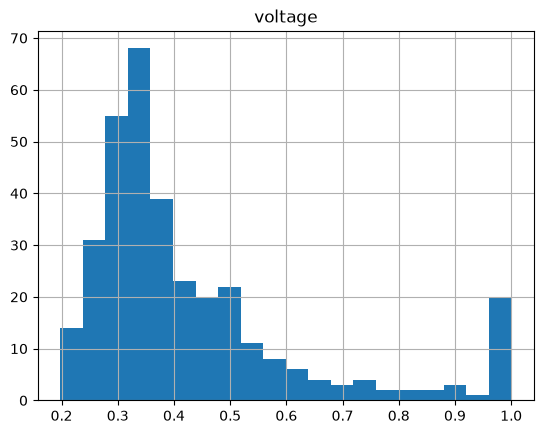

,mean,median,mode,min,max,Q1,Q3
0,0.431,0.36,1.0,0.198,1.0,0.31,0.483


<Figure size 640x480 with 0 Axes>

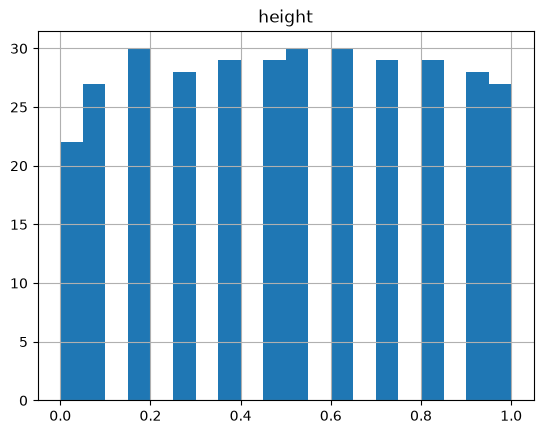

,mean,median,mode,min,max,Q1,Q3
0,0.509,0.545,0.182,0.0,1.0,0.273,0.727


<Figure size 640x480 with 0 Axes>

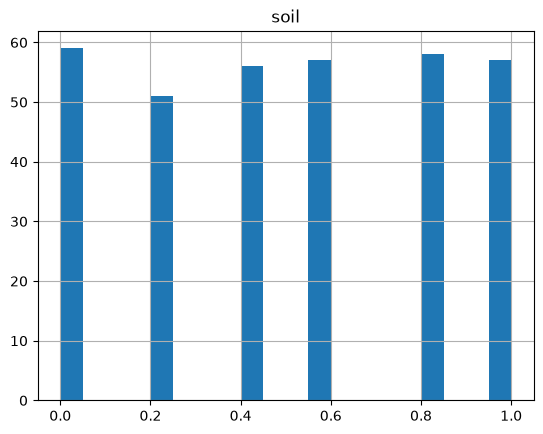

,mean,median,mode,min,max,Q1,Q3
0,0.504,0.6,0.0,0.0,1.0,0.2,0.8


<Figure size 640x480 with 0 Axes>

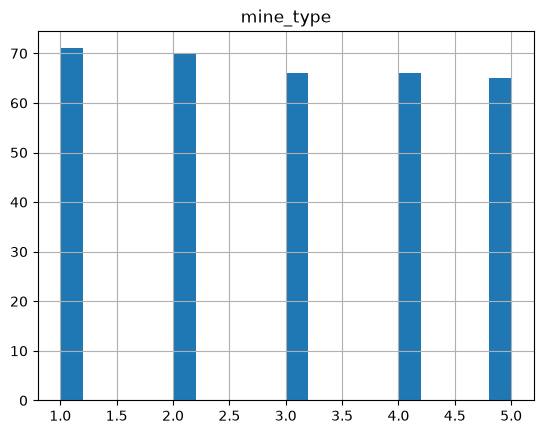

,mean,median,mode,min,max,Q1,Q3
0,2.953,3.0,1,1,5,2.0,4.0


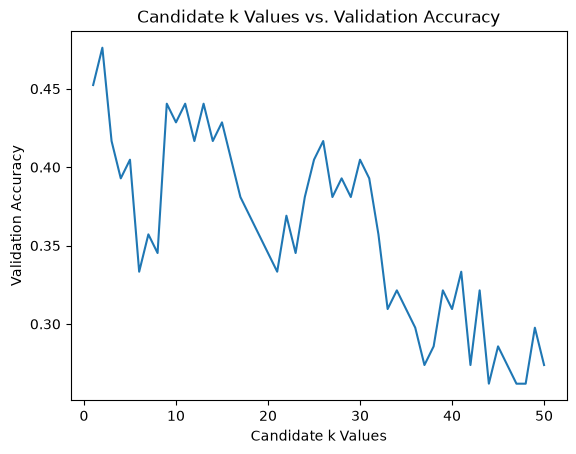

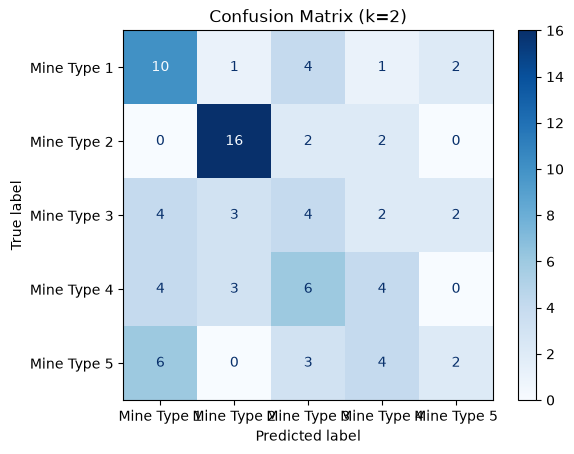

accuracy:  0.4235294117647059
Classification Report:
              precision    recall  f1-score   support

 Mine Type 1       0.42      0.56      0.48        18
 Mine Type 2       0.70      0.80      0.74        20
 Mine Type 3       0.21      0.27      0.24        15
 Mine Type 4       0.31      0.24      0.27        17
 Mine Type 5       0.33      0.13      0.19        15

    accuracy                           0.42        85
   macro avg       0.39      0.40      0.38        85
weighted avg       0.41      0.42      0.40        85



"\nNotice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. \nPlease explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.\n\nGiven the patterns in the errors the model makes, I would adivse someone who is using this predictive model in practice not to trust\nclassifications of Mine Types 3, 4, and 5, as these have high misclassification rates. For Mine Types 2 and 1, I would recommend someone\nto look at the probability distributions of classification predictions, as the additional context may be useful in making informed predictions\nabout classifications.\n"

In [ ]:
# Sources:
# https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbor-algorithm-in-python/
# https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

########## ========== Q2.1 ========== ##########
# Load the data. Perform some EDA, summarizing the target label and the features.
filepath = 'data/land_mines.csv'
df = pd.read_csv(filepath, low_memory=False)

print(df.shape, '\n')   # output: (338, 4)
print(df.dtypes, '\n') 
print(df.head())
print(df.info())        # output: all 4 columns have 338 non-nulls = no missing values

plt.figure()
df.hist(column="voltage", bins=20)  # create a histogram for the voltage column
plt.savefig("voltage_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the voltage variable with summary statistics
    "mean": [df["voltage"].mean()],
    "median": [df["voltage"].median()],
    "mode": [df["voltage"].mode().iloc[0]],
    "min" : df["voltage"].min(),
    "max": df["voltage"].max(),
    "Q1": [df["voltage"].quantile(0.25)],
    "Q3": [df["voltage"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode   min	    max	    Q1	    Q3
0.431	0.36	1.0	   0.198	1.0	   0.31	   0.483

Most skewed histogram, steep increase from around 0.2 to a peak around 0.35.
Then drops steeply again until around 0.45, then continues to decrease slowly.
Another sharp peak at 1.0.
'''

plt.figure()
df.hist(column="height", bins=20)  # create a histogram for the height column
plt.savefig("height_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the height variable with summary statistics
    "mean": [df["height"].mean()],
    "median": [df["height"].median()],
    "mode": [df["height"].mode().iloc[0]],
    "min" : df["height"].min(),
    "max": df["height"].max(),
    "Q1": [df["height"].quantile(0.25)],
    "Q3": [df["height"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode	min	   max	 Q1	     Q3
0.509	0.545	0.182	0.0	   1.0	 0.273	 0.727

Height ranges from 0.0-1.0, histogram has a slight peak in the middle.
Overall still relatively equally dustributed
'''

plt.figure()
df.hist(column="soil", bins=20)  # create a histogram for the soil column
plt.savefig("soil_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the soil variable with summary statistics
    "mean": [df["soil"].mean()],
    "median": [df["soil"].median()],
    "mode": [df["soil"].mode().iloc[0]],
    "min" : df["soil"].min(),
    "max": df["soil"].max(),
    "Q1": [df["soil"].quantile(0.25)],
    "Q3": [df["soil"].quantile(0.75)],
})
display(summary.round(3))

'''

mean	median	mode	min	   max	  Q1	Q3
0.504	0.6	     0.0	0.0	   1.0	  0.2	0.8

Soil values appear to be either 0.0, 0.2, 0.4, 0.6, 0.8, and 1.0.
Relatively evenly distributed.
'''

plt.figure()
df.hist(column="mine_type", bins=20)  # create a histogram for the mine_type column
plt.savefig("mine_type_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the mine_type variable with summary statistics
    "mean": [df["mine_type"].mean()],
    "median": [df["mine_type"].median()],
    "mode": [df["mine_type"].mode().iloc[0]],
    "min" : df["mine_type"].min(),
    "max": df["mine_type"].max(),
    "Q1": [df["mine_type"].quantile(0.25)],
    "Q3": [df["mine_type"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode	min	   max	   Q1	   Q3
2.953	3.0	     1	     1	    5	   2.0	   4.0

Observed that the 5 mine types are relatively evenly distributed.
'''


########## ========== Q2.2 ========== ##########
# Split the sample 50/50 into training and test/validation sets.
# (The smaller the data are, the more equal the split should be, in my experience:
# Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

# first split into 50/50 then split latter 50 into 50/50
# result: 50% train, 25% validate, 25% test
eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_test_raw,
    eval_y_train,
    eval_y_valid_test,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=65
)

(
    eval_X_valid_raw,
    classification_X_test_raw,
    eval_y_valid,
    classification_y_test,
) = train_test_split(
    eval_X_valid_test_raw, eval_y_valid_test, test_size=0.50, random_state=65
)

# fit the scalar on the training data, then transform both the training and validation data
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)


########## ========== Q2.3 ========== ##########
# Build a $k$-NN classifier.

# test out fitting the model on a range of k values
# for each k, create a classifier and fit it with that k value.
# predict results on the validation dataset and calculate the accuracy score
# choose the highest accuracy as eval_k_star
eval_ks = np.arange(1, 51)
eval_valid_accuracy = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_valid_accuracy.append(accuracy_score(eval_y_valid, eval_valid_hat))
eval_k_star = int(eval_ks[np.argmax(eval_valid_accuracy)])

# show the k vs validation accuracy scores plot
plt.plot(eval_ks, eval_valid_accuracy)
plt.xlabel("Candidate k Values")
plt.ylabel("Validation Accuracy")
plt.title(f"Candidate k Values vs. Validation Accuracy")
plt.show()

# fit the classifier on the best k value
classification_k = eval_k_star
classification_model = KNeighborsClassifier(n_neighbors = classification_k).fit(
    eval_X_train_scaled, eval_y_train
)

'''
Explain how you select k.

I selected k out of the range of values 1-51, which I copied from our slides.
However, it makes sense not to increase the range of candidate k values, since
our training dataset is only 338/2 = 169 entries and we have 5 classes, roughly
equally distributed. Larger k values would just result in underfitting.

For each k value, we create a new kNN classifier with that k and fit it on the 
training data. We then use the fitted model to predict y-hat of the validation
dataset. We calculate the accuracy score and store all scores of each k. After all
k values have been tested, we choose the one that had the highest accuracy score
as our best k.

I made a plot of the k values and accuracy scores to try to see the trend as the
k values increase. The progression is not smooth at all, with big jumps and dips,
but we definitely see that k=2 had the highest accuracy, and no other k value was
able to get nearly as high of an accuracy score. The overall trend is that after the
spike at k=2, the accuracy score gradually decreases until it reach ~0.33 at k=50.
'''


########## ========== Q2.4 ========== ##########
# Print a confusion table for the optimal model, comparing predicted and actual class label on the test set.

# predict on the test data
classification_X_test_scaled = eval_scaler.transform(classification_X_test_raw)
y_pred = classification_model.predict(classification_X_test_scaled)

# create the confusion matrix
cm = confusion_matrix(classification_y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mine Type 1", "Mine Type 2", "Mine Type 3", "Mine Type 4", "Mine Type 5"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k={classification_k})")
plt.grid(False)
plt.show()

print("accuracy: ", accuracy_score(classification_y_test, y_pred))
print("Classification Report:")
print(classification_report(classification_y_test, y_pred, target_names=["Mine Type 1", "Mine Type 2", "Mine Type 3", "Mine Type 4", "Mine Type 5"]))

'''
Classification Report:
              precision    recall  f1-score   support

 Mine Type 1       0.42      0.56      0.48        18
 Mine Type 2       0.70      0.80      0.74        20
 Mine Type 3       0.21      0.27      0.24        15
 Mine Type 4       0.31      0.24      0.27        17
 Mine Type 5       0.33      0.13      0.19        15

    accuracy                           0.42        85
   macro avg       0.39      0.40      0.38        85
weighted avg       0.41      0.42      0.40        85


How accurate is it? Where is performance more or less accurate?

The overall accuracy of the model is around 0.424. From our EDA in Q2.1, we observed that the five mine types were roughly evenly distributed. 
This means that classifying by chance would result in an average accuracy of around 20%. Therefore, the model is about twice as accurate as a
simple random classification.

When we look at the confusion matrix, we see some interesting patterns within. Precision describes performance on false positives: when the model 
predicted [class_x], how many times was it actually [class_x]? We observe that the model has the highest precision on Mine Type 2 with 70%. All other
mine types have majority false positives, with Mine Type 1 having a precision of 42%, followed by Mine Type 5, 4, and 3, with precisions of 33%, 31%,
and 21% respectively.

Recall describes performance on false negatives: when the class is [class_x], how many times does the model actually classify it as [class_x]?
We observe that the model makes the most accurate predictions for Mine Type 2 with 80.00% recall, followed by Mine Type 1 with 56% recall. For Mine 
Types 3 and 4, the model only predicts 4 classes correctly (27% and 24% recall, respectively). For Mine Type 5, the model only predicts 2 classes 
correctly (13% recall). 

The model often mistakes Mine Type 1 for Mine type 5, as well as Mine Type 3 for Mine Type 4 (6 misclassifications each). All other off-diagonal cells 
have misclassifications ranging from 0-4. Overall, with both precision and recall in mind, the model performs most accurately on Mine Type 2. The model
performs roughly semi-accurately on Mine Type 1, and performs poorly on Mine Types 3-5.
'''

########## ========== Q2.5 ========== ##########
'''
Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. 
Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Given the patterns in the errors the model makes, I would advise someone who is using this predictive model in practice not to trust classifications 
of Mine Types 1, 3, 4, and 5, as these have low precision/high misprediction rates. Only the classifications of Mine Type 2 are likely to be trustworthy, 
as when the model predicted Mine Type 2, it was correct 70% of the time. On the other hand, when the model predicted Mine Type 1, it was only correct 42%
of the time. Even worse, the precision scores of Mine Types 3, 4, and 5, ranged from 21%-33%. Even for Mine Type 2, a precision of 70% is not great, so I
recommend looking at the probability distributions of classification predictions, as the additional context may be useful in making informed decisions on
how to decide classifications.

'''

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]